<a href="https://colab.research.google.com/github/elizabethlee0613/NEUR3002/blob/main/ICA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

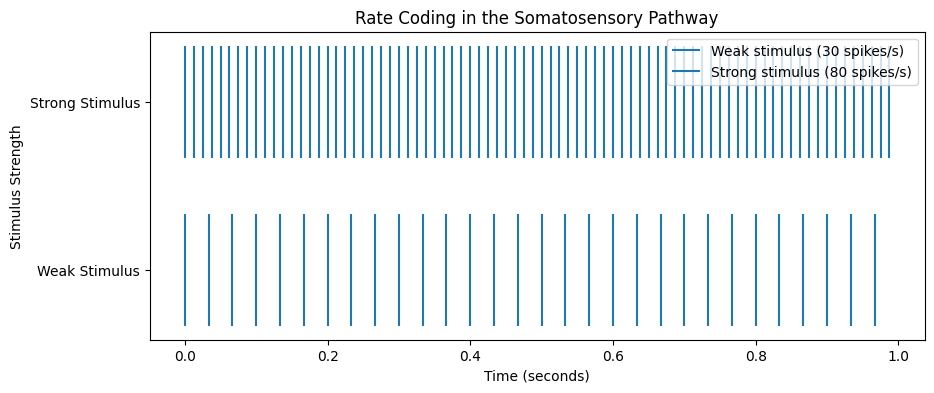

Weak stimulus:
Receptor potential = 6.0
Firing rate = 30.0 spikes/second

Strong stimulus:
Receptor potential = 16.0
Firing rate = 80.0 spikes/second


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Rate Coding in Somatosensory Pathway
# -----------------------------

# Total simulation time (seconds)
T = 1.0
dt = 0.001
time = np.arange(0, T, dt)

# Stimulus strengths
weak_stimulus = 0.3
strong_stimulus = 0.8

# Convert stimulus strength into receptor potential
# Stronger stimulus = greater receptor potential
def receptor_potential(stimulus):
    return stimulus * 20  # arbitrary units

# Convert receptor potential into firing rate
# Higher receptor potential = higher firing rate
def firing_rate(receptor_potential):
    return receptor_potential * 5  # spikes/second

# Calculate receptor potentials
weak_potential = receptor_potential(weak_stimulus)
strong_potential = receptor_potential(strong_stimulus)

# Calculate firing rates
weak_rate = firing_rate(weak_potential)
strong_rate = firing_rate(strong_potential)

# Generate evenly spaced spike times
weak_spikes = np.arange(0, T, 1 / weak_rate)
strong_spikes = np.arange(0, T, 1 / strong_rate)

# -----------------------------
# Plot the spike trains
# -----------------------------

plt.figure(figsize=(10, 4))

# Weak stimulus spikes
plt.vlines(
    weak_spikes,
    0.5,
    1.5,
    label=f"Weak stimulus ({weak_rate:.0f} spikes/s)"
)

# Strong stimulus spikes
plt.vlines(
    strong_spikes,
    2.0,
    3.0,
    label=f"Strong stimulus ({strong_rate:.0f} spikes/s)"
)

plt.yticks([1, 2.5], ["Weak Stimulus", "Strong Stimulus"])
plt.xlabel("Time (seconds)")
plt.ylabel("Stimulus Strength")
plt.title("Rate Coding in the Somatosensory Pathway")
plt.legend()

plt.show()

# Print results
print("Weak stimulus:")
print("Receptor potential =", weak_potential)
print("Firing rate =", weak_rate, "spikes/second")

print("\nStrong stimulus:")
print("Receptor potential =", strong_potential)
print("Firing rate =", strong_rate, "spikes/second")

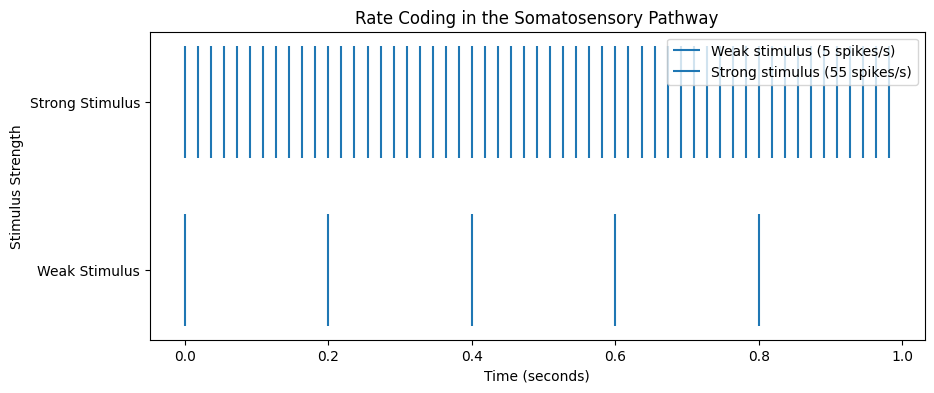

Weak stimulus:
Receptor potential = 6.0
Firing rate = 5.0 spikes/second

Strong stimulus:
Receptor potential = 16.0
Firing rate = 55.0 spikes/second


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Rate Coding in Somatosensory Pathway
# with a Firing Threshold
# -----------------------------

# Total simulation time (seconds)
T = 1.0

# Stimulus strengths
weak_stimulus = 0.3
strong_stimulus = 0.8

# Convert stimulus strength into receptor potential
# Stronger stimulus = greater receptor potential
def receptor_potential(stimulus):
    return stimulus * 20  # arbitrary units


# Convert receptor potential into firing rate
def firing_rate(receptor_potential):

    # Minimum receptor potential needed to generate action potentials
    threshold = 5

    # If receptor potential does not reach threshold,
    # the neuron does not fire
    if receptor_potential < threshold:
        return 0

    # If threshold is reached, firing rate increases
    # as receptor potential increases above threshold
    else:
        return (receptor_potential - threshold) * 5


# Calculate receptor potentials
weak_potential = receptor_potential(weak_stimulus)
strong_potential = receptor_potential(strong_stimulus)

# Calculate firing rates
weak_rate = firing_rate(weak_potential)
strong_rate = firing_rate(strong_potential)


# Generate spike times
# Only generate spikes if firing rate is greater than zero
if weak_rate > 0:
    weak_spikes = np.arange(0, T, 1 / weak_rate)
else:
    weak_spikes = []

if strong_rate > 0:
    strong_spikes = np.arange(0, T, 1 / strong_rate)
else:
    strong_spikes = []


# -----------------------------
# Plot spike trains
# -----------------------------

plt.figure(figsize=(10, 4))

plt.vlines(
    weak_spikes,
    0.5,
    1.5,
    label=f"Weak stimulus ({weak_rate:.0f} spikes/s)"
)

plt.vlines(
    strong_spikes,
    2.0,
    3.0,
    label=f"Strong stimulus ({strong_rate:.0f} spikes/s)"
)

plt.yticks([1, 2.5], ["Weak Stimulus", "Strong Stimulus"])
plt.xlabel("Time (seconds)")
plt.ylabel("Stimulus Strength")
plt.title("Rate Coding in the Somatosensory Pathway")
plt.legend()

plt.show()


# Print results
print("Weak stimulus:")
print("Receptor potential =", weak_potential)
print("Firing rate =", weak_rate, "spikes/second")

print("\nStrong stimulus:")
print("Receptor potential =", strong_potential)
print("Firing rate =", strong_rate, "spikes/second")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# REAL EXPERIMENTAL DATA
# ---------------------------------

# Stimulus strengths used in the experiment
stimulus_data = np.array([
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
])

# Measured firing rates from the experiment (spikes/second)
firing_rate_data = np.array([
    0,
    0,
    8,
    18,
    31,
    40,
    49,
    57
])


# ---------------------------------
# FIRING THRESHOLD
# ---------------------------------

threshold = 0.3


# ---------------------------------
# CREATE MODEL FROM REAL DATA
# ---------------------------------

def firing_rate(stimulus):

    # Below threshold, no action potentials occur
    if stimulus < threshold:
        return 0

    # Use experimental data to estimate firing rate
    return np.interp(
        stimulus,
        stimulus_data,
        firing_rate_data
    )


# ---------------------------------
# TEST THE MODEL
# ---------------------------------

stimulus = float(input("Enter stimulus strength: "))

rate = firing_rate(stimulus)

print("Stimulus strength:", stimulus)
print("Predicted firing rate:", rate, "spikes/second")


# ---------------------------------
# GENERATE ACTION POTENTIALS
# ---------------------------------

T = 1.0

if rate > 0:
    spike_times = np.arange(0, T, 1 / rate)
else:
    spike_times = []


# ---------------------------------
# PLOT ACTION POTENTIALS
# ---------------------------------

plt.figure(figsize=(10, 3))

plt.vlines(spike_times, 0, 1)

plt.xlabel("Time (seconds)")
plt.ylabel("Action Potentials")
plt.title(
    f"Somatosensory Rate Coding\n"
    f"Stimulus = {stimulus}, Firing Rate = {rate:.1f} spikes/s"
)

plt.yticks([])

plt.show()